Loading and preparing data...
Train shape: (26304, 11), Test shape: (6576, 11)
Features used: ['cow.1', 'hour', 'IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'rest_to_eat_ratio', 'hour_sin', 'hour_cos', 'cow_id', 'activity_rest_ratio']
Starting hyperparameter tuning with RandomizedSearchCV...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Hyperparameter tuning completed in 579.92 seconds
Best parameters: {'clf__estimator__solver': 'sgd', 'clf__estimator__max_iter': 500, 'clf__estimator__learning_rate_init': 0.1, 'clf__estimator__learning_rate': 'adaptive', 'clf__estimator__hidden_layer_sizes': (100, 100, 50), 'clf__estimator__batch_size': 64, 'clf__estimator__alpha': 0.01, 'clf__estimator__activation': 'tanh'}
Best CV score: 0.7425

Evaluating on test set...

OESTRUS PERFORMANCE
              precision    recall  f1-score   support

           0       0.79      0.96      0.87      4987
           1       0.62      0.21      0.32      1589

    accuracy                    

C:\Users\vishn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishn\anaconda3\Lib\site-packag

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      5912
           1       0.00      0.00      0.00       664

    accuracy                           0.90      6576
   macro avg       0.45      0.50      0.47      6576
weighted avg       0.81      0.90      0.85      6576


MASTITIS PERFORMANCE
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      6369
           1       0.00      0.00      0.00       207

    accuracy                           0.97      6576
   macro avg       0.48      0.50      0.49      6576
weighted avg       0.94      0.97      0.95      6576

Model saved

FINAL MODEL SUMMARY
Best parameters: {'clf__estimator__solver': 'sgd', 'clf__estimator__max_iter': 500, 'clf__estimator__learning_rate_init': 0.1, 'clf__estimator__learning_rate': 'adaptive', 'clf__estimator__hidden_layer_sizes': (100, 100, 50), 'clf__estimator__batch_size': 64, 'clf__estimator__alpha': 0.01, 

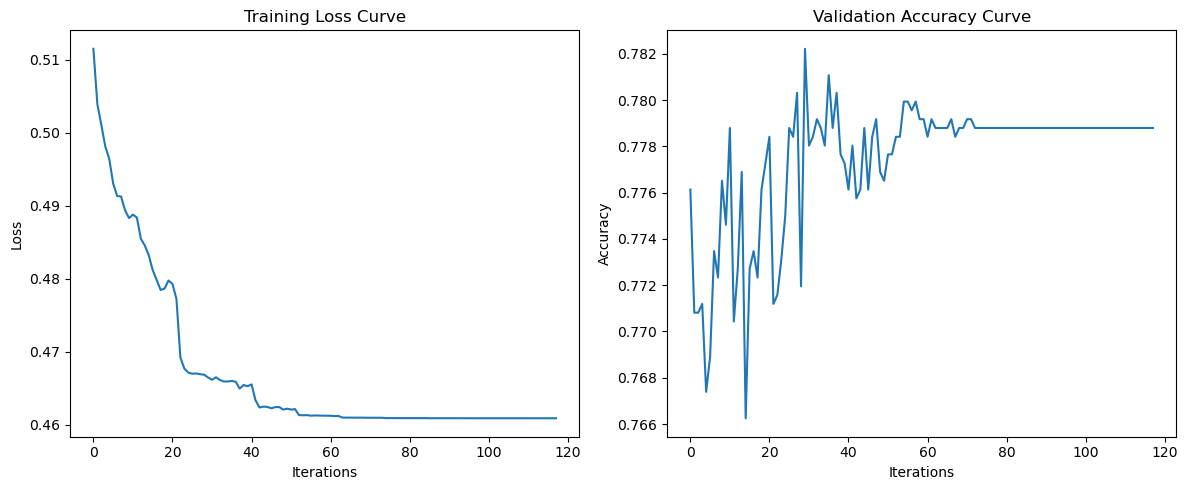

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
import joblib
import time

# 1. Load and prepare data
print("Loading and preparing data...")
df = pd.read_csv('balanced_datasets/multi_output_balanced.csv')

# Feature engineering
df['cow_id'] = df['cow'].astype('category').cat.codes  # Encode cow IDs
df['activity_rest_ratio'] = df['ACTIVITY_LEVEL'] / (df['REST'] + 1e-6)

# Remove problematic features
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 1', 'disturbance', 'cow', 'date'])

# Separate features and targets
X = df.drop(columns=['oestrus', 'calving', 'lameness', 'mastitis', 'any_disease'])
y = df[['oestrus', 'calving', 'lameness', 'mastitis']]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y['oestrus']
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Features used: {list(X.columns)}")

# 2. Create pipeline with scaling and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MultiOutputClassifier(
        MLPClassifier(
            early_stopping=True,  # Enable early stopping
            validation_fraction=0.1,
            random_state=42
        )
    ))
])

# 3. Hyperparameter tuning setup
param_dist = {
    'clf__estimator__hidden_layer_sizes': [(100,), (50, 50), (100, 50), (200, 100), (100, 100, 50)],
    'clf__estimator__activation': ['relu', 'tanh'],
    'clf__estimator__solver': ['adam', 'sgd'],
    'clf__estimator__alpha': [0.0001, 0.001, 0.01, 0.1],
    'clf__estimator__learning_rate': ['constant', 'adaptive'],
    'clf__estimator__learning_rate_init': [0.001, 0.01, 0.1],
    'clf__estimator__batch_size': [32, 64, 128],
    'clf__estimator__max_iter': [500]  # Will stop early if validation stops improving
}

# 4. Custom cross-validation for multi-output stratification
def multilabel_stratified_cv(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    dummy = y.iloc[:, 0]
    return skf.split(X, dummy)

# 5. Randomized Search with Cross-Validation
print("Starting hyperparameter tuning with RandomizedSearchCV...")
start_time = time.time()

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,  # Number of parameter combinations to try
    cv=multilabel_stratified_cv(X_train, y_train, n_splits=3),
    scoring='roc_auc_ovr_weighted',
    refit=True,
    random_state=42,
    verbose=3,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(f"Hyperparameter tuning completed in {time.time()-start_time:.2f} seconds")
print(f"Best parameters: {search.best_params_}")
print(f"Best CV score: {search.best_score_:.4f}")

# 6. Evaluate on test set
print("\nEvaluating on test set...")
y_pred = search.predict(X_test)
y_proba = search.predict_proba(X_test)  # List of arrays for each disease

# Classification report for each disease
diseases = ['oestrus', 'calving', 'lameness', 'mastitis']
test_results = {}

for i, disease in enumerate(diseases):
    print(f"\n{'='*50}\n{disease.upper()} PERFORMANCE\n{'='*50}")
    print(classification_report(y_test[disease], y_pred[:, i]))
    
    # Store metrics
    test_results[disease] = {
        'auc': roc_auc_score(y_test[disease], y_proba[i][:, 1])
    }

# 7. Save the best model
joblib.dump(search.best_estimator_, 'mlp_multioutput_model.joblib')
print("Model saved")

# 8. Final summary
print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Best parameters: {search.best_params_}")
print(f"Cross-validation AUC: {search.best_score_:.4f}")

for disease in diseases:
    print(f"{disease.upper()} Test AUC: {test_results[disease]['auc']:.4f}")

# 9. Training history visualization (for best model)
print("\nPlotting training history for best model...")
try:
    import matplotlib.pyplot as plt
    
    # Get the best MLP model for the first disease (representative)
    best_mlp = search.best_estimator_.named_steps['clf'].estimators_[0]
    
    # Plot training loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(best_mlp.loss_curve_)
    plt.title('Training Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    
    # Plot validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(best_mlp.validation_scores_)
    plt.title('Validation Accuracy Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    
    plt.tight_layout()
    plt.savefig('mlp_training_history.png')
    print("Training history plot saved as mlp_training_history.png")
except Exception as e:
    print(f"Could not generate training plots: {str(e)}")